# ECG Classification - Ensemble ML Models (v4)

This notebook implements traditional machine learning approaches using ensemble methods. Feature engineering from ECG signals combined with powerful ensemble methods.

**Input**: 188 columns of ECG time series data
**Output**: Binary classification (0 = normal, 1 = abnormal)

**Models**:
- Random Forest: 200 trees, max_depth=20, class_weight='balanced'
- XGBoost/GradientBoosting: 200 estimators, learning_rate=0.1
- Voting Ensemble: Soft voting combining both models

**Architecture (Features used)**:
- Basic Statistics: mean, std, max, min, range, median
- Higher-Order: skewness, kurtosis
- Signal Properties: RMS, variance, max_diff, mean_abs_diff
- Percentiles: p25, p75, IQR
- Temporal: zero_crossings (around baseline)
- Energy: sum of squared values

In [1]:
# Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import skew, kurtosis
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report, roc_auc_score
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, VotingClassifier
import warnings
warnings.filterwarnings('ignore')

# importing xgboost
try:
    from xgboost import XGBClassifier
    HAS_XGBOOST = True
except ImportError:
    HAS_XGBOOST = False
    print('XGBoost not available, using GradientBoosting instead')

## Data Loading

In [2]:
# Load data
try:
    df1 = pd.read_csv('/kaggle/input/ecg-dataset/ecg.csv', header=None)
    df2 = pd.read_csv('/kaggle/input/ecg2-dataset/ecg3.csv', header=None)
    df2 = df2.rename(columns={0: 'orig_0'})
    df2.insert(0, 0, df2['orig_0'])
    df2.columns = range(df2.shape[1])
    df = pd.concat([df1, df2], ignore_index=True)
except:
    df = pd.read_csv('../../dataset_aritmia_NEW.csv')

print(f'Dataset shape: {df.shape}')

Dataset shape: (5025, 189)


In [3]:
# Add column names
n_features = df.shape[1] - 1
column_names = [f'f{i}' for i in range(n_features)] + ['label']
df.columns = column_names
print(f'Number of features: {n_features}')
df.head()

Number of features: 188


,f0,f1,f2,f3,f4,f5,f6,f7,f8,f9,...,f179,f180,f181,f182,f183,f184,f185,f186,f187,label
0,955,954,954,956,958,955,955,953,954,956,...,941,940,940,939,941,941,942,937,938,0
1,952,953,953,953,949,947,953,952,953,952,...,946,949,951,947,948,946,949,949,951,0
2,955,948,952,952,955,955,954,953,955,958,...,939,934,935,934,937,935,930,933,932,0
3,957,958,958,958,956,956,956,959,959,959,...,939,939,942,942,940,938,935,936,937,0
4,958,958,960,960,958,958,959,961,961,961,...,944,946,949,949,950,947,946,946,946,0


In [4]:
# Check label distribution
print('Label distribution:')
print(df['label'].value_counts())
print('\nPercentage:')
print(df['label'].value_counts(normalize=True) * 100)

Label distribution:
label
0    2736
1    2289
Name: count, dtype: int64

Percentage:
label
0    54.447761
1    45.552239
Name: proportion, dtype: float64


## Feature Engineering

Extract statistical and morphological features from ECG signals.

In [5]:
def extract_ecg_features(signal):
    # Extract statistical features from ECG signal.
    features = {}
    
    # Basic statistics
    features['mean'] = np.mean(signal)
    features['std'] = np.std(signal)
    features['max'] = np.max(signal)
    features['min'] = np.min(signal)
    features['range'] = np.ptp(signal)
    features['median'] = np.median(signal)
    
    # Higher order statistics
    features['skewness'] = skew(signal)
    features['kurtosis'] = kurtosis(signal)
    
    # Signal characteristics
    features['rms'] = np.sqrt(np.mean(signal**2))
    features['variance'] = np.var(signal)
    
    # Peak detection (simple)
    diff = np.diff(signal)
    features['max_diff'] = np.max(np.abs(diff))
    features['mean_abs_diff'] = np.mean(np.abs(diff))
    
    # Percentiles
    features['p25'] = np.percentile(signal, 25)
    features['p75'] = np.percentile(signal, 75)
    features['iqr'] = features['p75'] - features['p25']
    
    # Zero crossings (around baseline +-958)
    baseline = np.mean(signal)
    centered = signal - baseline
    features['zero_crossings'] = np.sum(np.abs(np.diff(np.sign(centered))) > 0)
    
    # Energy
    features['energy'] = np.sum(signal**2)
    
    return features

In [6]:
# Extract features for all samples
X_raw = df.drop('label', axis=1).values
y = df['label'].values

# Extract engineered features
print('Extracting features...')
feature_list = []
for i, signal in enumerate(X_raw):
    features = extract_ecg_features(signal)
    feature_list.append(features)
    
X_engineered = pd.DataFrame(feature_list)
print(f'Engineered features shape: {X_engineered.shape}')
X_engineered.head()

Extracting features...
Engineered features shape: (5025, 17)


,mean,std,max,min,range,median,skewness,kurtosis,rms,variance,max_diff,mean_abs_diff,p25,p75,iqr,zero_crossings,energy
0,958.170745,42.114808,1216.0,910.0,306.0,946.0,4.393548,20.935181,959.095841,1773.657070,94.0,5.000000,942.0,958.0,16.0,4,1.729346e+08
1,956.606383,39.982235,1196.0,895.0,301.0,947.0,4.259483,20.172417,957.441565,1598.579108,82.0,4.882353,945.0,955.0,10.0,4,1.723385e+08
2,956.797872,37.604346,1188.0,911.0,277.0,946.0,4.371012,21.118832,957.536556,1414.086804,78.0,4.764706,943.0,958.0,15.0,10,1.723727e+08
3,959.053191,39.889039,1201.0,915.0,286.0,946.0,4.228069,19.803972,959.882368,1591.135469,78.0,4.823529,942.0,962.0,20.0,4,1.732183e+08
4,963.345745,42.478688,1213.0,917.0,296.0,951.0,4.293406,19.624267,964.281838,1804.438971,85.0,4.770053,947.0,963.0,16.0,6,1.748098e+08


In [7]:
# Combine raw features with engineered features
X_combined = np.hstack([X_raw, X_engineered.values])
print(f'Combined features shape: {X_combined.shape}')

Combined features shape: (5025, 205)


## Data Preprocessing

In [8]:
# Encode labels
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_combined)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

# Calculate class ratio for imbalanced handling
class_0_count = np.sum(y_train == 0)
class_1_count = np.sum(y_train == 1)
scale_pos_weight_value = class_0_count / class_1_count if class_1_count > 0 else 1
print(f'Class 0 count: {class_0_count}, Class 1 count: {class_1_count}')
print(f'Scale pos weight: {scale_pos_weight_value:.2f}')

print(f'\nTrain shape: {X_train.shape}')
print(f'Test shape: {X_test.shape}')

Class 0 count: 2189, Class 1 count: 1831
Scale pos weight: 1.20

Train shape: (4020, 205)
Test shape: (1005, 205)


## Model 1: Random Forest Classifier

In [9]:
# Random Forest
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=20,
    min_samples_split=5,
    min_samples_leaf=2,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

# Evaluate
rf_train_acc = rf_model.score(X_train, y_train)
rf_test_acc = rf_model.score(X_test, y_test)
print(f'Random Forest - Train Accuracy: {rf_train_acc:.4f}')
print(f'Random Forest - Test Accuracy: {rf_test_acc:.4f}')

Random Forest - Train Accuracy: 0.9988
Random Forest - Test Accuracy: 0.9960


In [10]:
# Cross-validation
cv_scores = cross_val_score(rf_model, X_scaled, y_encoded, cv=5, scoring='accuracy')
print(f'Random Forest - CV Accuracy: {cv_scores.mean():.4f} (+/- {cv_scores.std()*2:.4f})')

Random Forest - CV Accuracy: 0.9429 (+/- 0.1962)


## Model 2: XGBoost/Gradient Boosting Classifier

In [11]:
if HAS_XGBOOST:
    boost_model = XGBClassifier(
        n_estimators=200,
        max_depth=10,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=scale_pos_weight_value,
        random_state=42,
        use_label_encoder=False,
        eval_metric='logloss'
    )
    model_name = 'XGBoost'
else:
    boost_model = GradientBoostingClassifier(
        n_estimators=200,
        max_depth=10,
        learning_rate=0.1,
        subsample=0.8,
        random_state=42
    )
    model_name = 'GradientBoosting'

boost_model.fit(X_train, y_train)

# Evaluate
boost_train_acc = boost_model.score(X_train, y_train)
boost_test_acc = boost_model.score(X_test, y_test)
print(f'{model_name} - Train Accuracy: {boost_train_acc:.4f}')
print(f'{model_name} - Test Accuracy: {boost_test_acc:.4f}')

XGBoost - Train Accuracy: 1.0000
XGBoost - Test Accuracy: 0.9950


In [12]:
# Cross-validation
cv_scores = cross_val_score(boost_model, X_scaled, y_encoded, cv=5, scoring='accuracy')
print(f'{model_name} - CV Accuracy: {cv_scores.mean():.4f} (+/- {cv_scores.std()*2:.4f})')

XGBoost - CV Accuracy: 0.8957 (+/- 0.3831)


## Model 3: Voting Ensemble

In [13]:
# Create voting ensemble
ensemble_model = VotingClassifier(
    estimators=[
        ('rf', rf_model),
        ('boost', boost_model)
    ],
    voting='soft'
)

ensemble_model.fit(X_train, y_train)

# Evaluate
ens_train_acc = ensemble_model.score(X_train, y_train)
ens_test_acc = ensemble_model.score(X_test, y_test)
print(f'Ensemble - Train Accuracy: {ens_train_acc:.4f}')
print(f'Ensemble - Test Accuracy: {ens_test_acc:.4f}')

Ensemble - Train Accuracy: 1.0000
Ensemble - Test Accuracy: 0.9960


## Model Comparison and Evaluation

In [14]:
# Compare models
models = {
    'Random Forest': rf_model,
    model_name: boost_model,
    'Ensemble': ensemble_model
}

results = []
for name, model in models.items():
    y_pred = model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test)
    
    acc = model.score(X_test, y_test)
    roc_auc = roc_auc_score(y_test, y_pred_proba[:, 1])
    
    results.append({'Model': name, 'Accuracy': acc, 'ROC-AUC': roc_auc})

results_df = pd.DataFrame(results)
print('\nModel Comparison:')
print(results_df.to_string(index=False))


Model Comparison:
        Model  Accuracy  ROC-AUC
Random Forest  0.996020 0.999908
      XGBoost  0.995025 0.999908
     Ensemble  0.996020 0.999920


<Figure size 800x600 with 0 Axes>

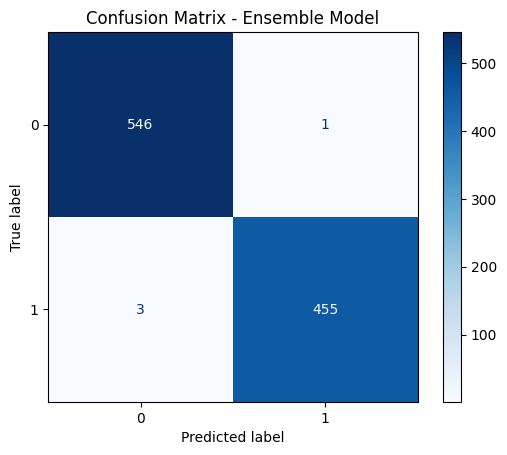

In [15]:
# Best model evaluation - use ensemble
best_model = ensemble_model
y_pred = best_model.predict(X_test)
y_pred_proba = best_model.predict_proba(X_test)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
disp.plot(cmap='Blues')
plt.title('Confusion Matrix - Ensemble Model')
plt.show()

In [16]:
# Classification Report
target_names = [str(label) for label in le.classes_]
print('\nClassification Report (Ensemble):')
print(classification_report(y_test, y_pred, target_names=target_names))


Classification Report (Ensemble):
              precision    recall  f1-score   support

           0       0.99      1.00      1.00       547
           1       1.00      0.99      1.00       458

    accuracy                           1.00      1005
   macro avg       1.00      1.00      1.00      1005
weighted avg       1.00      1.00      1.00      1005



In [17]:
# ROC-AUC Score
roc_auc = roc_auc_score(y_test, y_pred_proba[:, 1])
print(f'ROC-AUC Score: {roc_auc:.4f}')

ROC-AUC Score: 0.9999


## Feature Importance

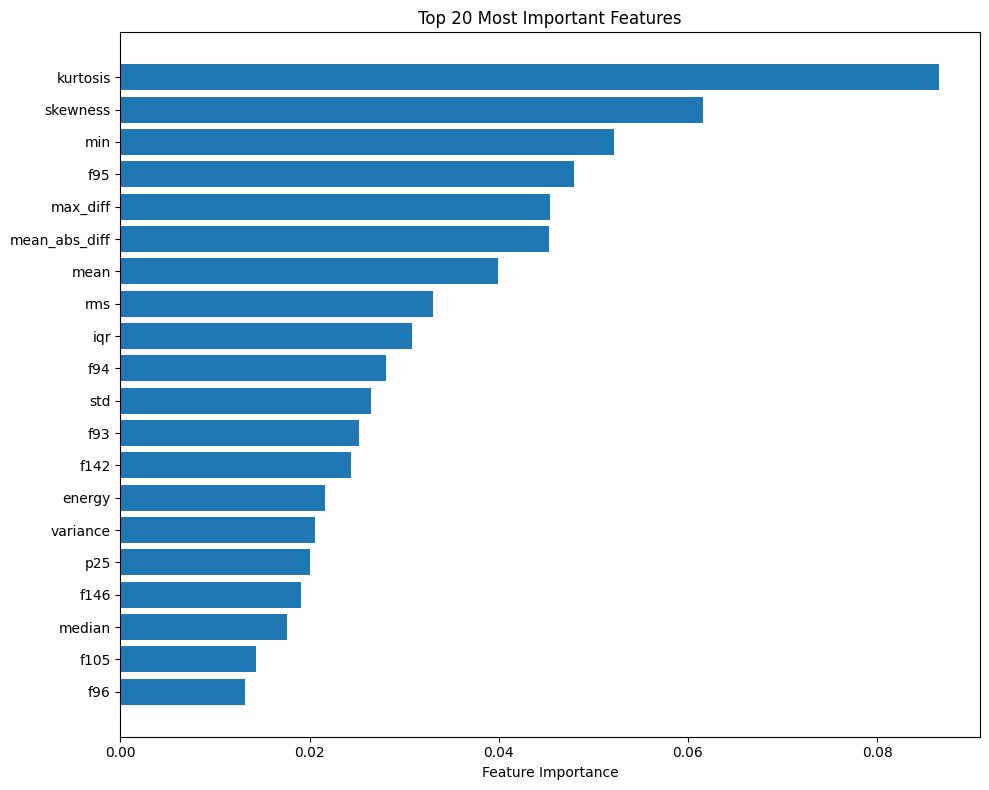

In [18]:
# Random Forest feature importance
feature_names = [f'f{i}' for i in range(n_features)] + list(X_engineered.columns)
importance = rf_model.feature_importances_

# Get top 20 features
indices = np.argsort(importance)[-20:]
plt.figure(figsize=(10, 8))
plt.barh(range(20), importance[indices])
plt.yticks(range(20), [feature_names[i] for i in indices])
plt.xlabel('Feature Importance')
plt.title('Top 20 Most Important Features')
plt.tight_layout()
plt.show()

## Prediction Function

In [19]:
def predict_ecg_ensemble(signal, model, scaler, label_encoder):
    # Extract features
    signal = np.array(signal)
    eng_features = extract_ecg_features(signal)
    
    # Combine raw and engineered features
    combined = np.hstack([signal, list(eng_features.values())]).reshape(1, -1)
    
    # Scale
    combined_scaled = scaler.transform(combined)
    
    # Predict
    y_pred = model.predict(combined_scaled)
    y_pred_proba = model.predict_proba(combined_scaled)
    
    predicted_label = label_encoder.inverse_transform(y_pred)[0]
    confidence = np.max(y_pred_proba)
    
    return predicted_label, confidence

In [20]:
# Test prediction with sample data (baseline ~958, peaks during beats)
sample_data = [
    952, 954, 956, 955, 955, 953, 952, 952, 951, 955, 953, 954, 952, 953, 952, 955,
    957, 958, 958, 962, 963, 964, 963, 965, 963, 967, 969, 971, 973, 973, 972, 971,
    973, 973, 972, 968, 966, 968, 970, 973, 969, 966, 960, 964, 965, 970, 971, 970,
    967, 964, 962, 961, 960, 954, 950, 951, 951, 951, 950, 950, 950, 948, 952, 949,
    949, 944, 940, 943, 944, 947, 948, 944, 941, 943, 945, 945, 945, 942, 938, 936,
    933, 926, 927, 920, 910, 909, 919, 940, 963, 986, 1020, 1068, 1121, 1167, 1193,
    1201, 1182, 1136, 1069, 1010, 967, 939, 924, 914, 917, 924, 931, 934, 934, 937,
    940, 942, 942, 941, 940, 939, 940, 938, 938, 936, 934, 934, 938, 938, 938, 935,
    935, 936, 939, 938, 938, 939, 935, 935, 938, 937, 937, 935, 935, 937, 938, 939,
    938, 938, 936, 940, 938, 939, 938, 936, 936, 938, 938, 941, 939, 938, 933, 935,
    935, 938, 938, 936, 936, 937, 938, 941, 941, 939, 939, 940, 943, 943, 941, 941,
    939, 938, 943, 943, 943, 943, 938, 941, 942, 941, 938, 935, 931, 932
]

predicted_label, confidence = predict_ecg_ensemble(sample_data, ensemble_model, scaler, le)
print(f'Prediction: {predicted_label}')
print(f'Confidence: {confidence:.4f}')
print(f'Expected: Normal (0)')

Prediction: 0
Confidence: 0.9999
Expected: Normal (0)


## Save Models

In [21]:
import joblib

# Save models
joblib.dump(rf_model, 'ecg_rf_model.pkl')
joblib.dump(boost_model, 'ecg_boost_model.pkl')
joblib.dump(ensemble_model, 'ecg_ensemble_model.pkl')
joblib.dump(scaler, 'ecg_scaler.pkl')
joblib.dump(le, 'ecg_label_encoder.pkl')

print('Models saved successfully!')

Models saved successfully!
